<a href="https://colab.research.google.com/github/Graciliana/Heart-disease-prediction/blob/main/01_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise Exploratória de Dados (EDA)

## 1. Objetivo

Este notebook tem como objetivo compreender a estrutura do conjunto de dados, identificar padrões, inconsistências e possíveis problemas que possam comprometer o treinamento dos modelos de Machine Learning. Serão realizadas análises estatísticas e visuais para apoiar as decisões das etapas de preparação dos dados e modelagem.

## 2. Importação das Bibliotecas

In [1]:
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
sns.set_theme(style="whitegrid")

from matplotlib.ticker import PercentFormatter

import plotly.express as px

from scipy.stats import skew
from IPython.display import Markdown

import os
import math
import glob

warnings.filterwarnings("ignore")

## 3. Configuração do Ambiente

In [2]:
JADE = "#00A93F"
color_discrete_sequence=[JADE]

plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["font.size"] = 11

plt.rcParams["axes.edgecolor"] = "#444444"
plt.rcParams["grid.alpha"] = 0.30
plt.rcParams["axes.grid"] = True

## 4. Carregamento da Base

In [3]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/sctech/Heart-disease-prediction/data/raw/heart_2020_cleaned.csv")


## 5. Visão Geral dos Dados

In [4]:
# @title Dimensões do dataset
display(Markdown("### Tamanho do Dataset"))
display(df.shape)
display(f'Linhas: {df.shape[0]}')
display(f'Colunas: {df.shape[1]}')

### Tamanho do Dataset

(319795, 18)

'Linhas: 319795'

'Colunas: 18'

In [5]:
# @title Primeiras linhas do Dataset
display(Markdown("### Primeiras linhas do Dataset"))
display(df.head())

### Primeiras linhas do Dataset

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No


In [6]:
# @title Informações Gerais
display(Markdown("### Informações Gerais"))
display(df.info())

### Informações Gerais

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319795 entries, 0 to 319794
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   HeartDisease      319795 non-null  object 
 1   BMI               319795 non-null  float64
 2   Smoking           319795 non-null  object 
 3   AlcoholDrinking   319795 non-null  object 
 4   Stroke            319795 non-null  object 
 5   PhysicalHealth    319795 non-null  float64
 6   MentalHealth      319795 non-null  float64
 7   DiffWalking       319795 non-null  object 
 8   Sex               319795 non-null  object 
 9   AgeCategory       319795 non-null  object 
 10  Race              319795 non-null  object 
 11  Diabetic          319795 non-null  object 
 12  PhysicalActivity  319795 non-null  object 
 13  GenHealth         319795 non-null  object 
 14  SleepTime         319795 non-null  float64
 15  Asthma            319795 non-null  object 
 16  KidneyDisease     31

None

In [7]:
# @title Quantidade de dados nullos
display(Markdown("### Quantidade de dados nullos"))
display(df.isnull().sum())

### Quantidade de dados nullos

,0
HeartDisease,0
BMI,0
Smoking,0
AlcoholDrinking,0
Stroke,0
PhysicalHealth,0
MentalHealth,0
DiffWalking,0
Sex,0
AgeCategory,0


In [8]:
# @title Quantidade de dados duplicados
display(Markdown("### Quantidade de dados duplicados"))
display(df.duplicated().sum())

### Quantidade de dados duplicados

np.int64(18078)

In [9]:
# @title Quantidade de dados únicos
display(Markdown("### Quantidade de dados únicos"))
display(df.nunique())

### Quantidade de dados únicos

,0
HeartDisease,2
BMI,3604
Smoking,2
AlcoholDrinking,2
Stroke,2
PhysicalHealth,31
MentalHealth,31
DiffWalking,2
Sex,2
AgeCategory,13


In [10]:
# @title Tipos das variáveis
display(Markdown("### Tipos das variáveis"))
display(df.dtypes.value_counts())

### Tipos das variáveis

,count
object,14
float64,4


In [11]:
# @ title Lista das Variaveis
display(Markdown("### Lista das Variaveis"))
pd.DataFrame({
    "Variável": df.columns,
    "Tipo": df.dtypes.values
})

### Lista das Variaveis

,Variável,Tipo
0,HeartDisease,object
1,BMI,float64
2,Smoking,object
3,AlcoholDrinking,object
4,Stroke,object
5,PhysicalHealth,float64
6,MentalHealth,float64
7,DiffWalking,object
8,Sex,object
9,AgeCategory,object


In [12]:
# @title Memória utilizada
display(Markdown("### Memória utilizada"))
display(f"{df.memory_usage().sum() / 1024 ** 2:.2f} MB")

### Memória utilizada

'43.92 MB'

### Principais observações

- O conjunto de dados possui 319795 registros e 18 atributos.
- Foram identificadas variáveis numéricas e categóricas, indicando a necessidade de diferentes técnicas de pré-processamento.
- A variável alvo (HeartDisease) é categórica binária.
- Nesta etapa não foram identificados problemas estruturais aparentes; as verificações de valores ausentes, duplicados e outliers serão realizadas nas próximas seções.



## 6. Estatísticas Descritivas

In [13]:
# @title Estatísticas descritivas
display(Markdown("### Estatísticas descritivas"))
display(df.describe().T.round(2))

### Estatísticas descritivas

,count,mean,std,min,25%,50%,75%,max
BMI,319795.0,28.33,6.36,12.02,24.03,27.34,31.42,94.85
PhysicalHealth,319795.0,3.37,7.95,0.00,0.00,0.00,2.00,30.00
MentalHealth,319795.0,3.90,7.96,0.00,0.00,0.00,3.00,30.00
SleepTime,319795.0,7.10,1.44,1.00,6.00,7.00,8.00,24.00


In [14]:
numericas = df.select_dtypes(include=np.number).columns
# @title Tabela de estatisticas
estatisticas = pd.DataFrame({
    "Média": df[numericas].mean(),
    "Mediana": df[numericas].median(),
    "Desvio Padrão": df[numericas].std(),
    "Coeficiente de Variação (%)":
        (df[numericas].std()/df[numericas].mean()*100),
    "Assimetria": df[numericas].skew()
}).round(2)

display(estatisticas)

,Média,Mediana,Desvio Padrão,Coeficiente de Variação (%),Assimetria
BMI,28.33,27.34,6.36,22.44,1.33
PhysicalHealth,3.37,0.00,7.95,235.81,2.60
MentalHealth,3.90,0.00,7.96,204.07,2.33
SleepTime,7.10,7.00,1.44,20.23,0.68


| Valor da Assimetria | Interpretação             |
| ------------------: | ------------------------- |
|    entre -0.5 e 0.5 | aproximadamente simétrica |
|       entre 0.5 e 1 | assimetria moderada       |
|         maior que 1 | fortemente assimétrica    |


In [15]:
# @title Estatísticas descritivas categóricas
display(Markdown("### Estatísticas descritivas categóricas"))
display(df.describe(include="object").T)

### Estatísticas descritivas categóricas

,count,unique,top,freq
HeartDisease,319795,2,No,292422
Smoking,319795,2,No,187887
AlcoholDrinking,319795,2,No,298018
Stroke,319795,2,No,307726
DiffWalking,319795,2,No,275385
Sex,319795,2,Female,167805
AgeCategory,319795,13,65-69,34151
Race,319795,6,White,245212
Diabetic,319795,4,No,269653
PhysicalActivity,319795,2,Yes,247957


In [16]:
# @title Tabela de cardinalidade
categoricas = df.select_dtypes(include="object").columns

cardinalidade = pd.DataFrame({
    "Variável": categoricas,
    "Categorias": [df[col].nunique() for col in categoricas]
})

display(cardinalidade)

,Variável,Categorias
0,HeartDisease,2
1,Smoking,2
2,AlcoholDrinking,2
3,Stroke,2
4,DiffWalking,2
5,Sex,2
6,AgeCategory,13
7,Race,6
8,Diabetic,4
9,PhysicalActivity,2


### Principais observações

• Variáveis com coeficiente de variação elevado apresentam maior dispersão.

• Variáveis com assimetria superior a |1| indicam distribuições assimétricas.

• Essas informações serão utilizadas para decidir o tratamento de valores ausentes e outliers.

## 7. Análise Da Variável Alvo (HeartDisease)

### Distribuição da variável alvo

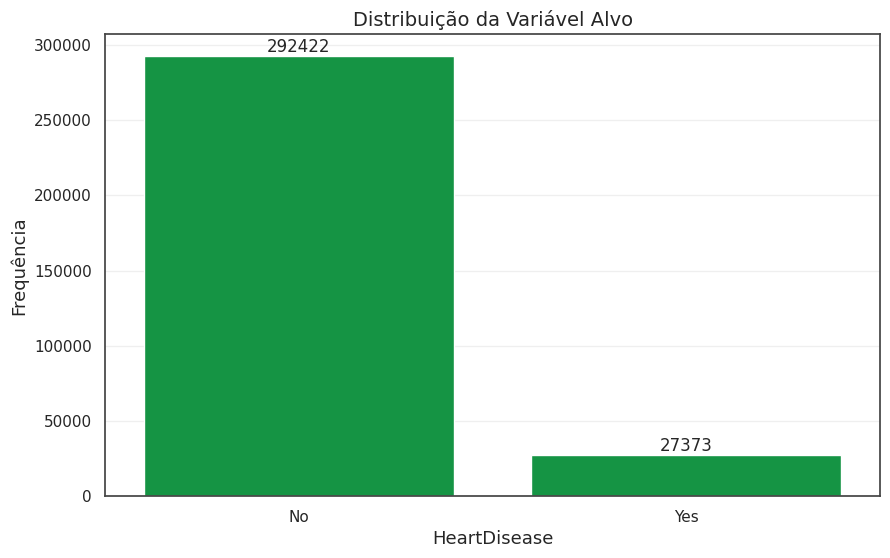

In [17]:
# @title Distribuição da variável alvo
display(Markdown("### Distribuição da variável alvo"))
# criar os grafico
plt.figure(figsize=(10, 6))

ax = sns.countplot(
    data=df,
    x="HeartDisease",
    palette=color_discrete_sequence
)
ax.set_xticklabels(["No", "Yes"])

plt.title("Distribuição da Variável Alvo", fontsize=14)
plt.xlabel("HeartDisease")
plt.ylabel("Frequência")

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.0f}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=12
    )
plt.show()


In [18]:
# @title Frequencia absoluta
display(Markdown("### Frequência absoluta"))
display(df["HeartDisease"].value_counts())

### Frequência absoluta

,count
HeartDisease,
No,292422
Yes,27373


In [19]:
# @title Frequência Relativa
display(Markdown("### Frequência relativa"))
display(df["HeartDisease"].value_counts(normalize=True))

### Frequência relativa

,proportion
HeartDisease,
No,0.914405
Yes,0.085595


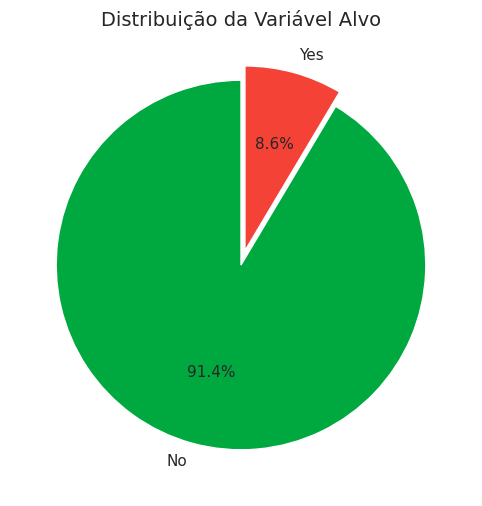

In [20]:
plt.figure(figsize=(12, 6))

plt.pie(
    df["HeartDisease"].value_counts(),
    labels=["No", "Yes"],
    autopct="%1.1f%%",
    startangle=90,
    explode=(0,0.08),
    colors=["#00A93F", "#F44336"]
)

plt.title("Distribuição da Variável Alvo", fontsize=14)
plt.show()

In [21]:
# @title Tabela resumo
display(Markdown("### Tabela resumo"))
target_summary = (
    pd.concat(
        [
            df["HeartDisease"].value_counts(),
            df["HeartDisease"].value_counts(normalize=True).mul(100)
        ],
        axis=1
    )
)

target_summary.columns = [
    "Frequência",
    "Percentual (%)"
]

display(target_summary.round(2))

### Tabela resumo

,Frequência,Percentual (%)
HeartDisease,,
No,292422,91.44
Yes,27373,8.56


In [22]:
# @title Analise do balanceamento das classes
display(Markdown("### Grau de Desbalanceamento"))

class_counts = df['HeartDisease'].value_counts(normalize=True) * 100

classe_majoritaria_valor = class_counts.max()
classe_majoritaria_nome = class_counts.idxmax()

classe_minoritaria_valor = class_counts.min()
classe_minoritaria_nome = class_counts.idxmin()

print(f"Classe majoritária ({classe_majoritaria_nome}): {classe_majoritaria_valor:.2f}%")
print(f"Classe minoritária ({classe_minoritaria_nome}): {classe_minoritaria_valor:.2f}%")

### Grau de Desbalanceamento

Classe majoritária (No): 91.44%
Classe minoritária (Yes): 8.56%


### Interpretação dos resultados
A variável alvo apresenta forte desbalanceamento entre as classes. Aproximadamente 91% dos registros pertencem à classe "No", enquanto apenas 9% representam a classe "Yes". Esse comportamento poderá influenciar o treinamento dos modelos, tornando importante avaliar métricas além da acurácia e considerar técnicas de balanceamento, como o SMOTE, durante a etapa de modelagem.

### Impacto na modelagem
- Accuracy sozinha pode ser enganosa.
- Precision, Recall e F1-Score serão utilizadas na comparação dos modelos.

## 8. Análise das Variáveis Numéricas

In [23]:


JADE = "#00A93F"

def plot_numeric_variables(
    df: pd.DataFrame,
    columns: list[str] | None = None,
    bins: int = 30,
    figsize: tuple = (14, 5),
) -> None:
    """
    Gera um histograma e um boxplot lado a lado para cada variável numérica.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame contendo os dados.

    columns : list[str], optional
        Lista das colunas numéricas. Caso None,
        todas as colunas numéricas serão utilizadas.

    bins : int
        Número de classes do histograma.

    figsize : tuple
        Tamanho da figura.
    """

    if columns is None:
        columns = df.select_dtypes(include="number").columns

    for col in columns:

        fig, axes = plt.subplots(
            1,
            2,
            figsize=figsize,
            gridspec_kw={"width_ratios": [4, 1]}
        )

        # Histograma
        sns.histplot(
            data=df,
            x=col,
            bins=bins,
            kde=True,
            color=JADE,
            alpha=0.85,
            ax=axes[0]
        )
        axes[0].axvline(df[col].mean(), color="red", linestyle="--", label="Média")
        axes[0].axvline(df[col].median(), color="blue", label="Mediana")
        axes[0].legend()
        axes[0].set_title(f"Histograma - {col}")
        axes[0].set_xlabel(col)
        axes[0].set_ylabel("Frequência")

        # Boxplot
        sns.boxplot(
            data=df,
            y=col,
            color=JADE,
            width=0.4,
            ax=axes[1]
        )

        axes[1].set_title(f"Boxplot - {col}")
        axes[1].set_ylabel(col)

        plt.suptitle(
            f"Distribuição da Variável {col}",
            fontsize=15,
            fontweight="bold"
        )

        plt.tight_layout()

        plt.show()

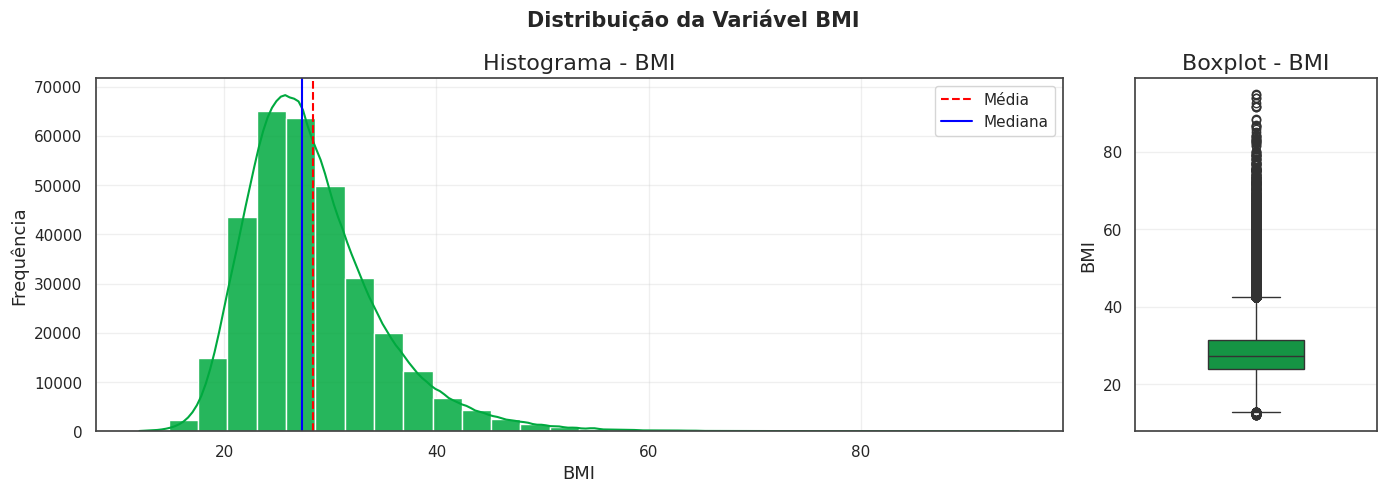

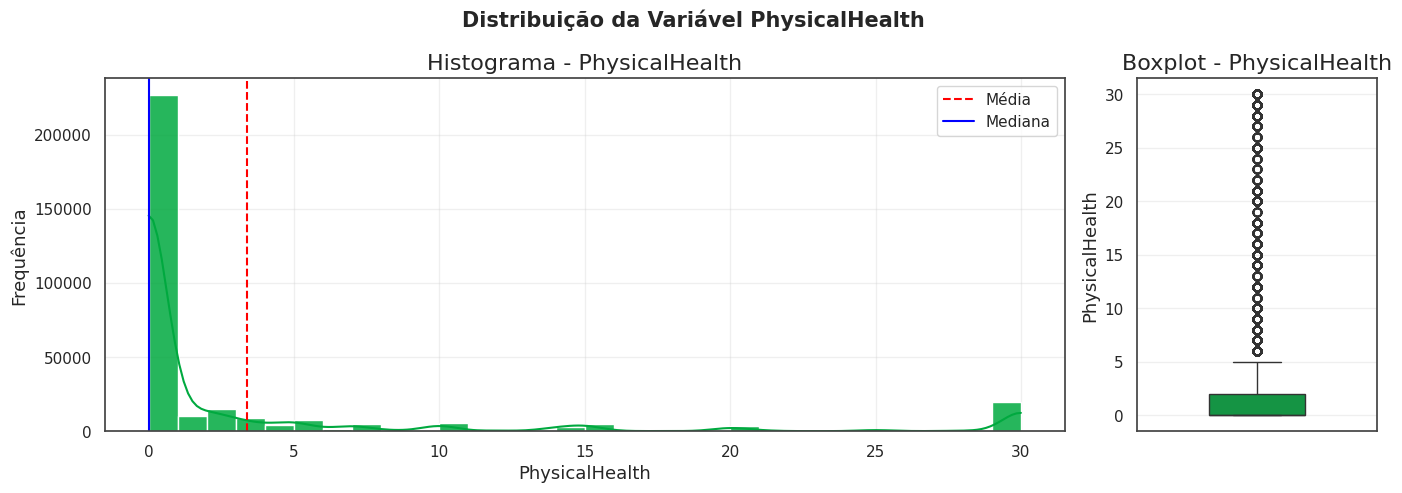

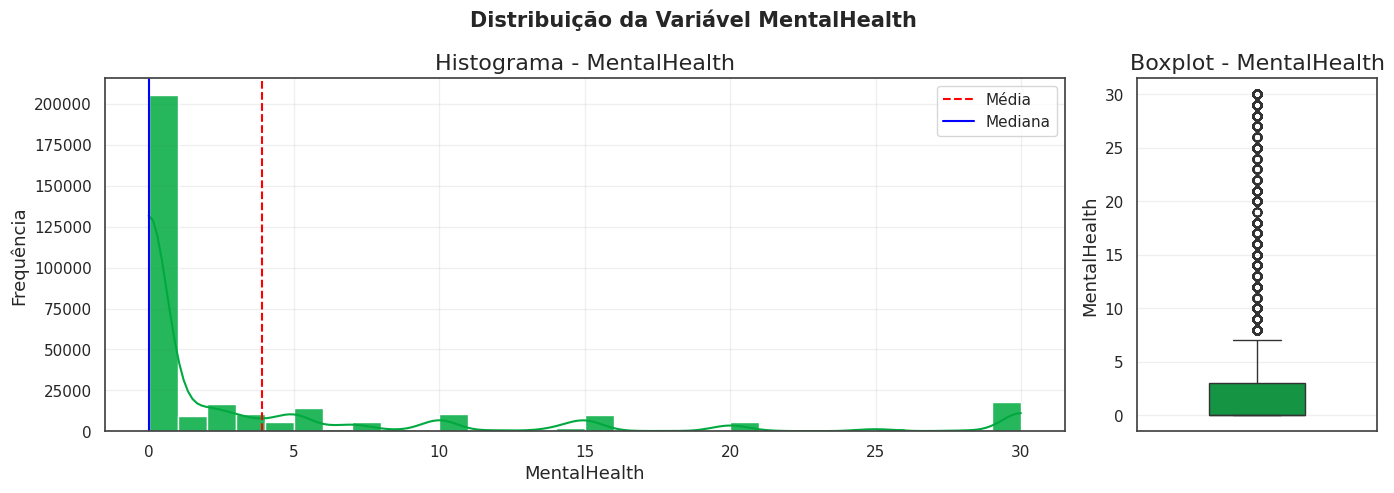

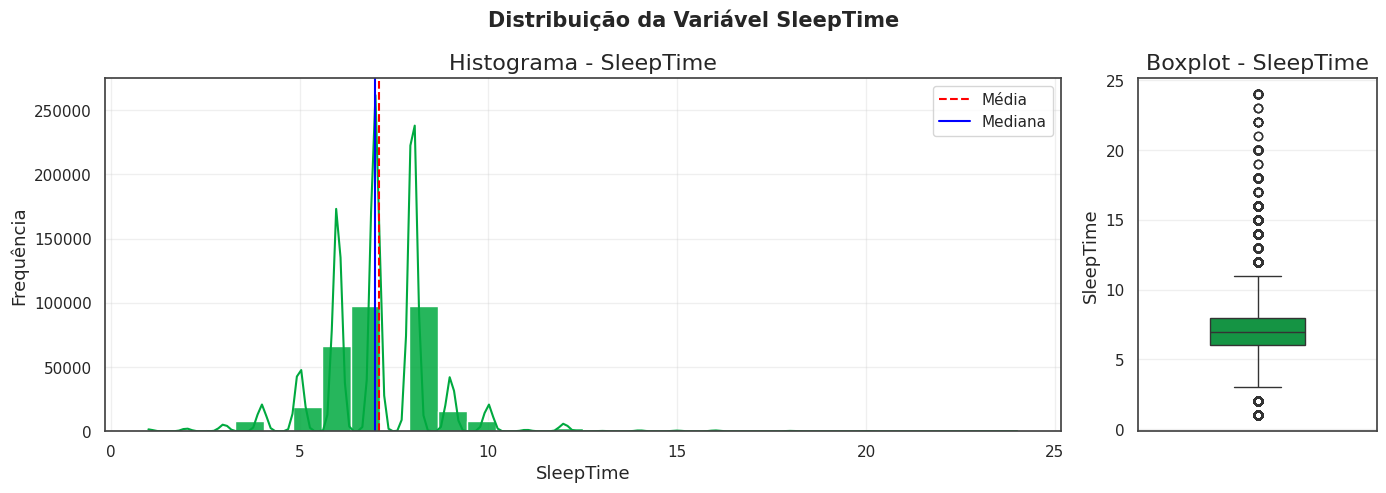

In [24]:
numeric_columns = [
    "BMI",
    "PhysicalHealth",
    "MentalHealth",
    "SleepTime"
]

plot_numeric_variables(df, numeric_columns)

## 9. Análise das Variáveis Categóricas

In [25]:


JADE = "#00A93F"

def plot_all_categorical(df):

    cat_cols = df.select_dtypes(include=["object", "category"]).columns

    n = len(cat_cols)
    ncols = 2
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(16, 5*nrows)
    )

    axes = axes.flatten()

    for ax, col in zip(axes, cat_cols):

        sns.countplot(
            data=df,
            x=col,
            color=JADE,
            ax=ax
        )

        ax.set_title(col, fontsize=13)

        if df[col].nunique() > 4:
            ax.tick_params(axis="x", rotation=45)

        for container in ax.containers:
            ax.bar_label(container, fontsize=8)

    # Remove eixos vazios
    for ax in axes[len(cat_cols):]:
        fig.delaxes(ax)

    plt.tight_layout()
    plt.show()

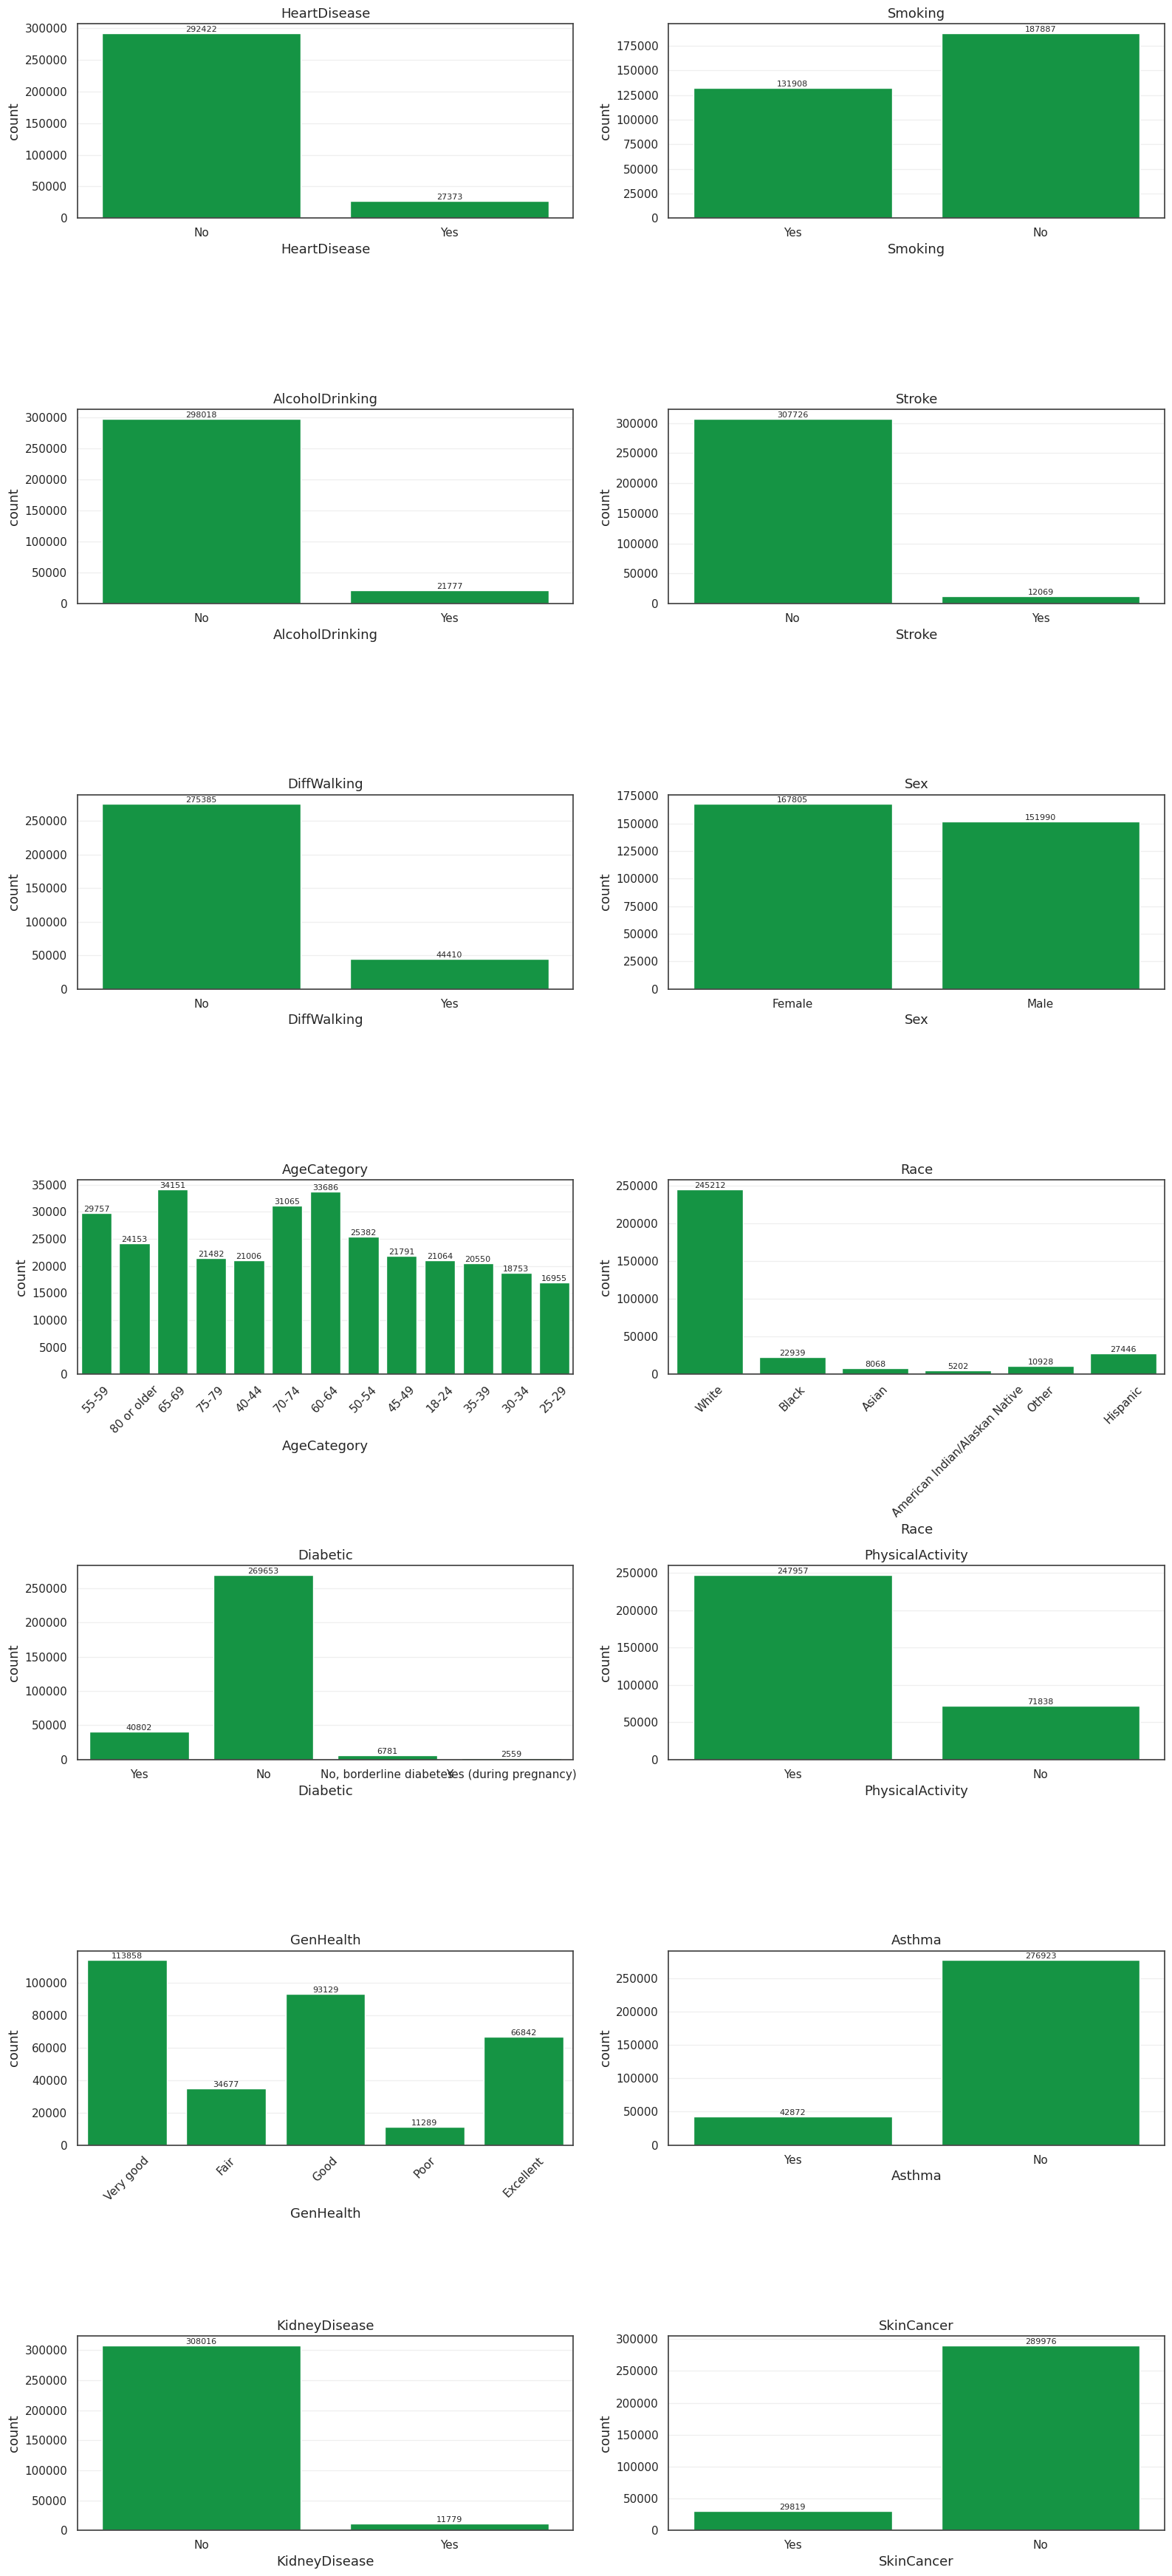

In [26]:

plot_all_categorical(df)

## 10. Matriz de correlação

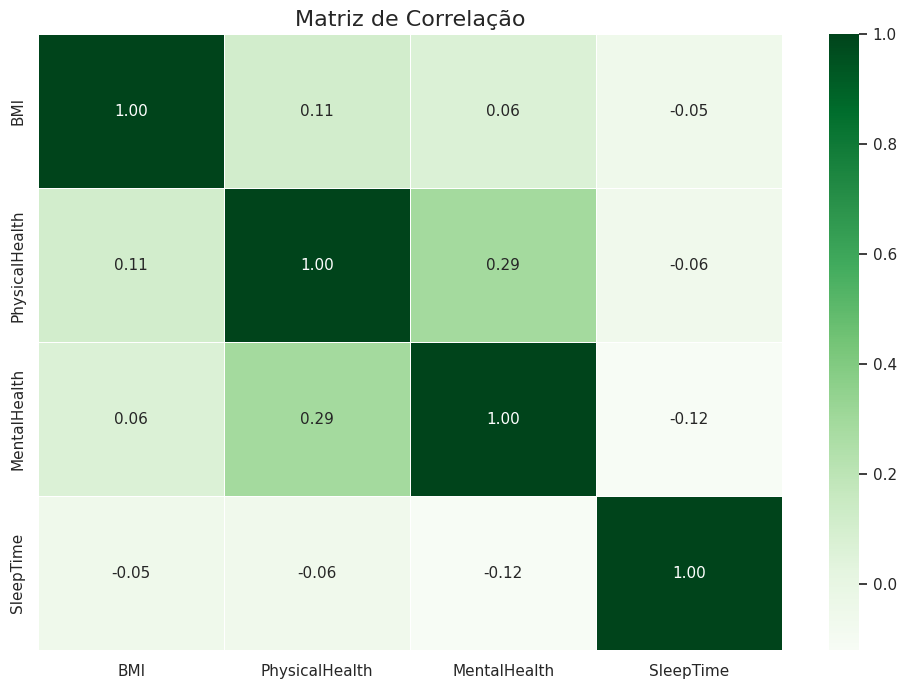

In [27]:
plt.figure(figsize=(12,8))

correlation = df[numeric_columns].corr()

sns.heatmap(
    correlation,
    cmap="Greens",
    annot=True,
    fmt=".2f",
    linewidths=.5
)

plt.title("Matriz de Correlação", fontsize=16)
plt.show()

## 11. Valores Ausentes

In [28]:

missing = pd.DataFrame({
    "Valores Ausentes": df.isna().sum(),
    "Percentual (%)": (
        df.isna().mean()*100
    ).round(2)
})

missing = missing[
    missing["Valores Ausentes"] > 0
]
display(Markdown("### Valores Ausentes"))
display(missing)

### Valores Ausentes

,Valores Ausentes,Percentual (%)


> não possui valores ausentes

## 12. Registros Duplicados


In [29]:
duplicates = df.duplicated().sum()
display(Markdown("### Registros Duplicados"))
print(f"Registros duplicados: {duplicates}")

### Registros Duplicados

Registros duplicados: 18078


In [30]:
display(Markdown("### Percentual duplicados"))
print(
    f"Percentual: "
    f"{duplicates/len(df)*100:.2f}%"
)

### Percentual duplicados

Percentual: 5.65%


> Existem registros duplicados mas que representa 5.65% dos dados. Serão tratados no notebook 2

## 13. Análise de Outliers


In [31]:


JADE = "#00A93F"

def plot_boxplots(
    df: pd.DataFrame,
    columns: list[str] | None = None,
    ncols: int = 2,
    figsize: tuple = (16, 5)
) -> None:
    """
    Plota boxplots das variáveis numéricas e identifica
    visualmente possíveis outliers utilizando o método IQR.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame contendo os dados.

    columns : list[str], optional
        Lista de variáveis numéricas.
        Caso None, todas as variáveis numéricas serão utilizadas.

    ncols : int, default=2
        Número de gráficos por linha.

    figsize : tuple, default=(16,5)
        Tamanho base de cada linha de gráficos.

    Returns
    -------
    None
    """

    if columns is None:
        columns = df.select_dtypes(include="number").columns.tolist()

    nrows = math.ceil(len(columns) / ncols)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(figsize[0], figsize[1] * nrows)
    )

    axes = axes.flatten()

    for ax, col in zip(axes, columns):

        sns.boxplot(
            data=df,
            y=col,
            color=JADE,
            width=0.45,
            linewidth=1.2,
            fliersize=4,
            ax=ax
        )

        # ---------- Estatísticas ----------
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        outliers = df[(df[col] < lower) | (df[col] > upper)]

        ax.set_title(
            f"{col}\nOutliers: {len(outliers):,}",
            fontsize=13,
            fontweight="bold"
        )

        ax.set_ylabel(col)

        ax.grid(axis="y", alpha=0.3)

    # Remove eixos vazios
    for ax in axes[len(columns):]:
        fig.delaxes(ax)

    plt.suptitle(
        "Análise de Outliers das Variáveis Numéricas",
        fontsize=18,
        fontweight="bold"
    )

    plt.tight_layout()

    plt.show()

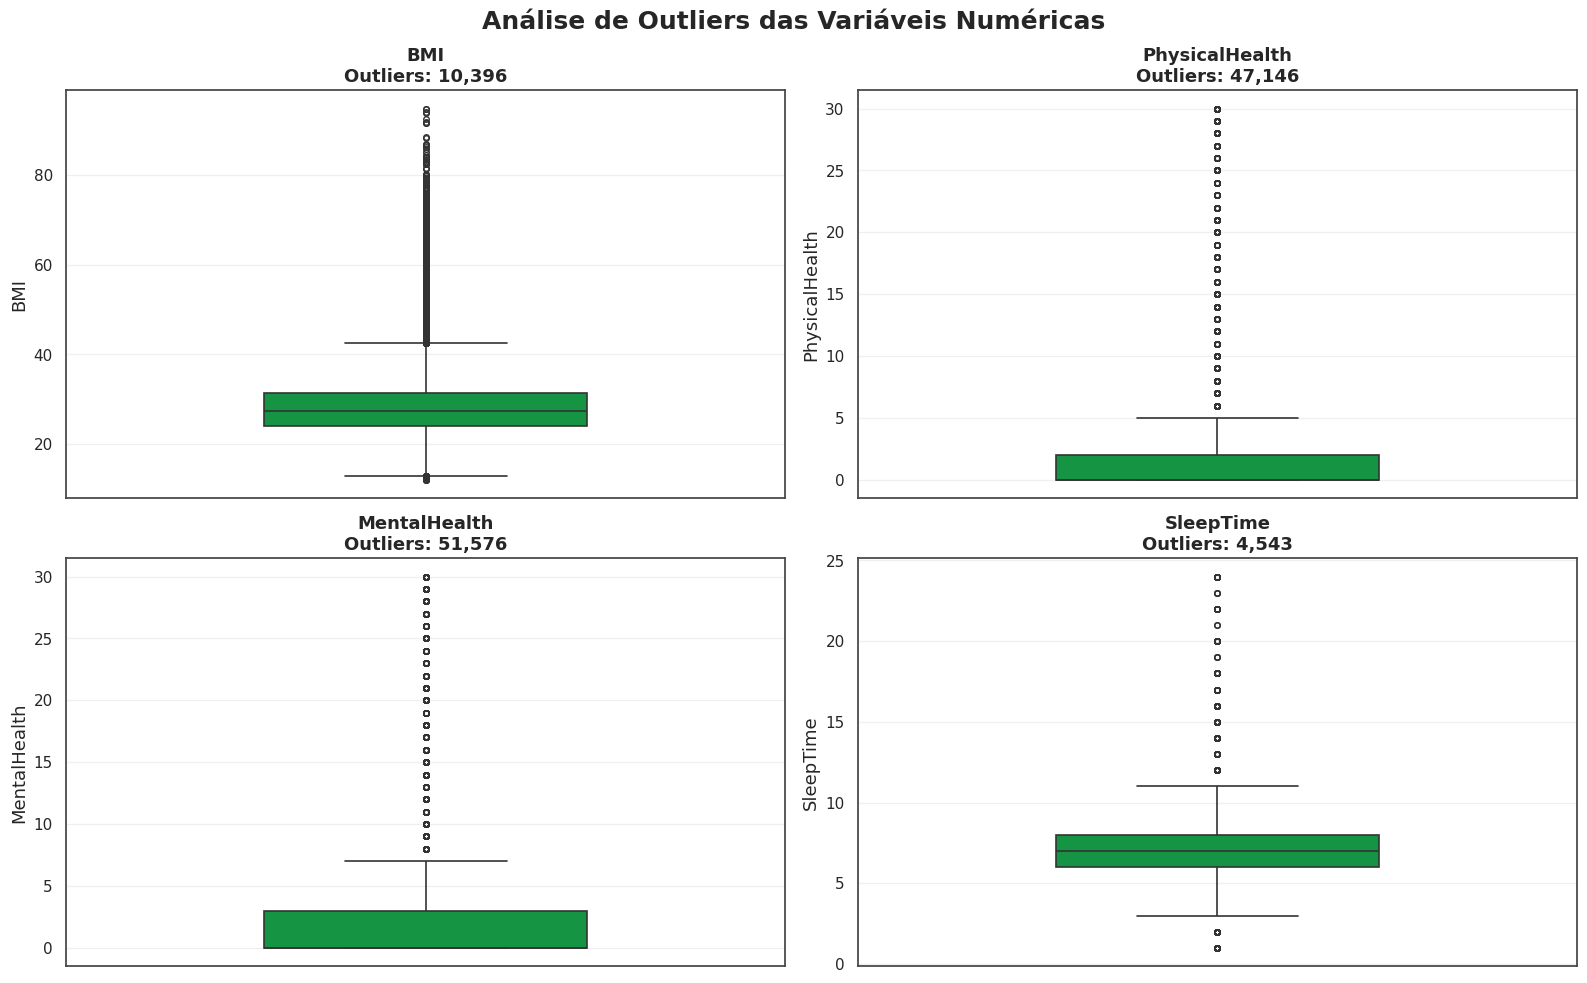

In [32]:
plot_boxplots(df)

In [33]:
def outlier_summary(
    df: pd.DataFrame,
    columns: list[str] | None = None
) -> pd.DataFrame:
    """
    Retorna um resumo da quantidade de outliers
    pelo método do IQR para cada variável numérica.
    """

    if columns is None:
        columns = df.select_dtypes(include="number").columns.tolist()

    resumo = []

    for col in columns:

        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)

        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()

        resumo.append({
            "Variável": col,
            "Outliers": n_outliers,
            "Percentual (%)": round(
                n_outliers / len(df) * 100,
                2
            )
        })

    return (
        pd.DataFrame(resumo)
        .sort_values("Outliers", ascending=False)
        .reset_index(drop=True)
    )

In [34]:
display(outlier_summary(df))

,Variável,Outliers,Percentual (%)
0,MentalHealth,51576,16.13
1,PhysicalHealth,47146,14.74
2,BMI,10396,3.25
3,SleepTime,4543,1.42


> Principais observações: **As variáveis com maior quantidade de outliers foram identificadas pelo método do IQR. Nesta etapa, os outliers são apenas analisados e quantificados. A decisão de tratá-los, removê-los ou mantê-los será tomada no Notebook 02 (Pré-processamento), considerando seu impacto no desempenho dos modelos de Machine Learning. Isso deixa a EDA descritiva e reserva as transformações para a etapa apropriada do projeto.

## 14.Insights da EDA
319795, 18

- O conjunto de dados possui 319795 registros e 18 atributos.
- A variável alvo apresenta desbalanceamento entre as classes.
- As variáveis numéricas apresentam diferentes níveis de dispersão.
- Algumas distribuições apresentam forte assimetria.
- Não foram identificados valores ausentes.
- Existem registros duplicados que serão tratados posteriormente.
- Algumas variáveis apresentam outliers, que serão avaliados na etapa de pré-processamento.